# Fig. 3 minimal scan: figures from the saved npz

Redraws the two figures of the byproduct-mobility scan
(`20260727_run_fig3scan.py`) from the checkpointed results in
`20260727_fig3scan_peaks.npz`.

**Nothing is simulated here.** The npz already holds everything both figures need:
the peak traces, the recording time grid, the mobilities, and the linear-stability
numbers (`k_star`, `max_growth`, `L_box`) that the runs computed.

**This notebook is self-contained.** Every function it uses is defined below,
transcribed from `20260727_fig3scan_functions.py` so that the panels, colours,
normalisations and labels are the same as the code that produced the saved
PNG/SVG files. Nothing is imported from the scan's own modules.

The figures reproduced are:

1. `20260727_fig3scan_peaks.png` -- peak count against time, one band per
   $p = D_x/D_{\rm ext}$ (replicate mean with min--max spread);
2. `20260727_fig3scan_final.png` -- peak count reached at $t_{\max}$ against $p$,
   with the linear-instability prediction $L/\lambda^*$ for reference.

In [1]:
import pathlib

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal
from matplotlib.colors import LogNorm

# --- Plotting style -------------------------------------------------------- #
# This is both the user's global style and, verbatim, the style the original
# script set for these two figures, so there is nothing to reconcile.
sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": ".9", "grid.linestyle": "--",
                            "axes.edgecolor": ".6", "xtick.bottom": True,
                            "ytick.left": True})

colorTable = {}
colorTable["k"] = [0, 0, 0]
colorTable["g"] = [27 / 255, 158 / 255, 119 / 255]
colorTable["o"] = [217 / 255, 95 / 255, 2 / 255]

WD = pathlib.Path.cwd()
STEM = "20260727_fig3scan"
NPZ = WD / f"{STEM}_peaks.npz"
print(f"working directory: {WD}")
print(f"npz: {NPZ.name}  ({NPZ.stat().st_size / 1e3:.0f} kB)")

working directory: /media/kabir/8331fe27-69c5-463e-a8db-719f7dc905ef/home/kabir/Work/UCL/Projects/2025 Spatial Ecology/20260410 Jans Code/SSMC-python/Consolidated/Fig 3 Minimal Scan
npz: 20260727_fig3scan_peaks.npz  (150 kB)


## Functions

The helpers the two figures need, transcribed from
`20260727_fig3scan_functions.py`: `formed_peaks`, `p_shades`,
`plot_peaks_vs_time`, `plot_final_peaks`, and the `SWEEP_CMAP` colour map they
default to. Defining them here rather than importing them keeps the notebook
standing on its own, and means it still draws what the saved figures show even if
the module is later edited.

Note the reading convention `formed_peaks` encodes for the saved `peaks` array:
NaN marks a replicate that was never run, and **zero is a real measurement**
meaning the run happened but the field was still too flat to hold peaks. Neither
is the count of a pattern, so both become NaN and the nan-aware statistics skip
them. To ask *when* patterns formed, use the array as saved rather than this
view -- the zeros carry that information and are discarded here.

In [2]:
SWEEP_CMAP = pal.matplotlib.Viridis_20.mpl_colormap


def formed_peaks(peaks):
    """Peak counts restricted to times at which a pattern exists, as floats.

    The ``peaks`` array a scan saves holds NaN where a replicate was never run, and zero
    where the run happened but the field was still too flat to hold peaks. Neither is a
    count of a pattern, so averaging over them would report a coarsening that did not
    happen; both become NaN here and the nan-aware statistics skip them.
    """
    peaks = np.asarray(peaks, dtype=float)
    return np.where(peaks > 0, peaks, np.nan)


def p_shades(ps):
    """Map a set of ``p`` values onto [0, 1] in log space, for colouring by mobility."""
    ps = np.asarray(ps, dtype=np.float64)
    if ps.min() >= ps.max():
        return np.full(ps.size, 0.5)
    return np.asarray(LogNorm(vmin=ps.min(), vmax=ps.max())(ps), dtype=np.float64)


def plot_peaks_vs_time(ax, t, peaks, ps, cmap=SWEEP_CMAP, n_peaks_target=None,
                       label_fmt: str = "$p={:.3g}$"):
    """Draw peak count against time: the replicate mean per ``p``, with its spread.

    ``peaks`` is ``(n_p, n_replicates, n_times)`` as saved by a scan. Replicates of one
    ``p`` differ only in their seeding noise and coarsen at slightly different moments, so
    the individual traces are shown as a shaded min-max band behind the mean rather than
    as many lines.

    Both axes are logarithmic: pattern formation and coarsening are decades apart in
    time, and the counts span more than an order of magnitude across ``p``. Each curve
    averages only over the replicates that have a pattern at that time
    (``formed_peaks``), so the band shows the spread in peak count and not the spread in
    when the pattern appeared. A dashed line marks the number of peaks the boxes were
    sized to hold.
    """
    t = np.asarray(t, dtype=float)
    peaks = formed_peaks(peaks)

    for row, p, shade in zip(peaks, ps, p_shades(ps)):
        # Restrict to the times where at least one replicate has a pattern before taking
        # statistics: the nan-aware reductions warn on an all-NaN column.
        formed = np.any(np.isfinite(row), axis=0)
        if not formed.any():
            continue
        row = row[:, formed]
        color = cmap(float(shade))
        ax.fill_between(t[formed], np.nanmin(row, axis=0), np.nanmax(row, axis=0),
                        color=color, alpha=0.25, lw=0)
        ax.plot(t[formed], np.nanmean(row, axis=0), color=color, lw=2,
                label=label_fmt.format(p))

    if n_peaks_target is not None:
        ax.axhline(n_peaks_target, color=".5", ls="--", lw=1, zorder=0)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("$t$")
    ax.set_ylabel("number of peaks")
    return ax


def plot_final_peaks(ax, ps, final, color=(27 / 255, 158 / 255, 119 / 255),
                     n_peaks_target=None):
    """Draw the peak count reached at ``t_max`` against ``p``, over the replicates.

    ``final`` is ``(n_p, n_replicates)``. Individual replicates are drawn as faint points
    so the scatter at a given ``p`` is visible next to their mean. Values of ``p`` where
    no pattern had formed by ``t_max`` are left out rather than plotted at zero, which a
    logarithmic count axis cannot show.
    """
    ps = np.asarray(ps, dtype=float)
    final = formed_peaks(final)

    # Same masking idiom as plot_peaks_vs_time: a p whose replicates all came back empty
    # would make the nan-aware mean warn, and is simply left off the line.
    mean = np.full(ps.size, np.nan)
    formed = np.any(np.isfinite(final), axis=1)
    mean[formed] = np.nanmean(final[formed], axis=1)

    ax.plot(np.repeat(ps, final.shape[1]), final.ravel(), "o", color=color, alpha=0.35,
            ms=5, mew=0, zorder=1)
    ax.plot(ps, mean, "o-", color=color, lw=2, ms=8, label="replicate mean", zorder=2)
    if n_peaks_target is not None:
        ax.axhline(n_peaks_target, color=".5", ls="--", lw=1, zorder=0,
                   label="linear instability ($L/\\lambda^*$)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("$p = D_x / D_{\\rm ext}$")
    ax.set_ylabel("number of peaks")
    return ax

## What the npz contains

Layout, with `n_p` mobilities, `n_rep` replicates and `n_times` recording times
(from the docstring of `save_npz` in the run script):

| key | shape | meaning |
| --- | --- | --- |
| `p` | (n_p,) | byproduct mobilities $p = D_x/D_{\rm ext}$ scanned |
| `seeds` | (n_p, n_rep) | the noise seed of every run, so any one can be reproduced |
| `t` | (n_times,) | the logarithmic recording grid shared by every run |
| `peaks` | (n_p, n_rep, n_times) | the result: peak count at each time. NaN = replicate never ran; **0 is a real measurement** meaning the field was still too flat to hold peaks |
| `done`, `success` | (n_p, n_rep) | which slots ran, and which reached $t_{\max}$ |
| `k_star`, `max_growth`, `L_box` | (n_p,) | linear stability and box length; these follow from `p` alone, so replicates share them |
| `t_max`, `ssize`, `n_peaks`, `K` | scalars | the configuration |

In [3]:
data = dict(np.load(NPZ))

print(f"{'key':<12} {'shape':<16} {'dtype':<10} value / range")
print("-" * 78)
for key, arr in data.items():
    arr = np.asarray(arr)
    if arr.ndim == 0:
        summary = f"{arr.item():g}"
    elif arr.size <= 8:
        summary = np.array2string(arr, precision=4, separator=", ")
    elif arr.dtype == bool:
        summary = f"{arr.sum()} / {arr.size} True"
    else:
        summary = (f"[{np.nanmin(arr):g} ... {np.nanmax(arr):g}]"
                   f"  ({np.isnan(arr).sum()} NaN)" if arr.dtype.kind == "f"
                   else f"[{arr.min()} ... {arr.max()}]")
    print(f"{key:<12} {str(arr.shape):<16} {str(arr.dtype):<10} {summary}")

key          shape            dtype      value / range
------------------------------------------------------------------------------
p            (6,)             float64    [0.05, 0.1 , 0.25, 0.5 , 1.  , 2.  ]
seeds        (6, 10)          uint32     [1093169 ... 4247155308]
t            (300,)           float64    [0.1 ... 1e+08]  (0 NaN)
peaks        (6, 10, 300)     float64    [0 ... 111]  (0 NaN)
done         (6, 10)          bool       60 / 60 True
success      (6, 10)          bool       60 / 60 True
t_max        ()               float64    1e+08
ssize        ()               int64      2048
n_peaks      ()               int64      100
K            ()               float64    5
k_star       (6,)             float64    [4.9717, 4.5117, 3.9916, 3.6816, 3.4215, 3.1815]
max_growth   (6,)             float64    [0.1097, 0.0853, 0.0516, 0.0296, 0.0132, 0.0029]
L_box        (6,)             float64    [126.3779, 139.265 , 157.4102, 170.6668, 183.6376, 197.4927]


In [4]:
ps = data["p"]
t = data["t"]
peaks = data["peaks"]
n_peaks_target = int(data["n_peaks"])
t_max = float(data["t_max"])
n_reps = peaks.shape[1]

print(f"n_p = {ps.size}, n_replicates = {n_reps}, n_times = {t.size}")
print(f"t from {t[0]:g} to {t[-1]:g};  t_max = {t_max:g}")
print(f"boxes sized for n_peaks = {n_peaks_target} wavelengths, ssize = {int(data['ssize'])}, K = {float(data['K']):g}")
print(f"runs done: {data['done'].sum()} / {data['done'].size};  "
      f"solver reached t_max in {data['success'].sum()} of them")

n_p = 6, n_replicates = 10, n_times = 300
t from 0.1 to 1e+08;  t_max = 1e+08
boxes sized for n_peaks = 100 wavelengths, ssize = 2048, K = 5
runs done: 60 / 60;  solver reached t_max in 60 of them


### Summary table

The same table the run script prints via `print_summary`, recomputed here from the
stored arrays. A zero count would mean a run finished with no pattern, and is
reported as such rather than averaged in as a count of zero peaks.

In [5]:
final = formed_peaks(peaks[:, :, -1])
n_run = data["done"].sum(axis=1)

print(f"\n{'p':>7} {'k*':>7} {'growth':>9}   peaks at t_max (mean [min, max])")
for i, p in enumerate(ps):
    formed = final[i][np.isfinite(final[i])]
    if n_run[i] == 0:
        stats = "(no runs)"
    elif formed.size == 0:
        stats = "(no pattern in any replicate)"
    else:
        stats = f"{formed.mean():6.1f} [{formed.min():.0f}, {formed.max():.0f}]"
        if formed.size < n_run[i]:
            stats += f"  ({n_run[i] - formed.size} with no pattern)"
    print(f"{p:>7g} {data['k_star'][i]:>7.3f} {data['max_growth'][i]:>+9.4f}   {stats}")


      p      k*    growth   peaks at t_max (mean [min, max])
   0.05   4.972   +0.1097     99.9 [97, 101]
    0.1   4.512   +0.0853     96.1 [93, 98]
   0.25   3.992   +0.0516     85.8 [84, 87]
    0.5   3.682   +0.0296     62.7 [60, 66]
      1   3.422   +0.0132      9.3 [8, 10]
      2   3.181   +0.0029      6.5 [6, 7]


## Figure 1 -- coarsening vs byproduct mobility (`..._peaks.png`)

Peak count against time, one curve per $p$. Replicates of one $p$ differ only in
their seeding noise and coarsen at slightly different moments, so the ten
individual traces appear as a shaded min--max band behind their mean rather than
as ten lines. Both axes are logarithmic; the dashed grey line marks the
$L/\lambda^* = 100$ peaks each box was sized to hold.

Colour encodes $p$ through `p_shades`, a `LogNorm` between the smallest and
largest $p$, fed to `palettable.matplotlib.Viridis_20` -- dark purple at
$p = 0.05$ up to yellow at $p = 2$.

Each curve averages only over the replicates that have a pattern *at that time*
(`formed_peaks`), so the band shows the spread in peak count and not the spread in
when the pattern appeared. Curves start where the first replicate leaves zero,
around $t \approx 40$.

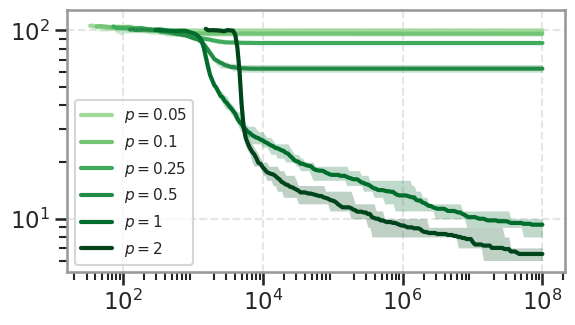

In [48]:
fig, ax = plt.subplots(figsize=(6, 3.5))
initialpeaks = 100

cmap=SWEEP_CMAP

thesecmaps = pal.colorbrewer.sequential.Blues_9.mpl_colors[3:]

thesecmaps = pal.colorbrewer.sequential.Greens_9.mpl_colors[3:]

label_fmt = "$p={:.3g}$"
formedpeaks = formed_peaks(peaks)
indexy = np.arange(len(ps))

for row, p, shade, thiscolor in zip(formedpeaks, ps, p_shades(ps), thesecmaps):
    # Restrict to the times where at least one replicate has a pattern before taking
    # statistics: the nan-aware reductions warn on an all-NaN column.
    formed = np.any(np.isfinite(row), axis=0)
    if not formed.any():
        continue
    row = row[:, formed]
    color = cmap(float(shade))

    color = thiscolor
    ax.fill_between(t[formed], np.nanmin(row, axis=0), np.nanmax(row, axis=0),
                    color=color, alpha=0.25, lw=0)
    ax.plot(t[formed], np.nanmean(row, axis=0), "-", color=color, lw=3,
            label=label_fmt.format(p))

# if initialpeaks is not None:
#     ax.axhline(initialpeaks, color=".5", ls="--", lw=1, zorder=0)

ax.set_xscale("log")
ax.set_yscale("log")
# ax.set_xlabel("$t$")
# ax.set_ylabel("number of aggregates")

# ax.set_ylim(1, 1.1 * initialpeaks)
# ax.set_ylim(0, 1.1 * initialpeaks)
ax.set_xticks(10**np.arange(2, 9, 2))

# Place legend at bottom left of panel
ax.legend(loc="lower left", fontsize=11, ncol=1, frameon=True)

# ax.legend(ncol=2, frameon=False)
# ax.set_title(f"coarsening vs byproduct mobility  "
#              f"({n_reps} replicates, $t_{{\\max}}$={t_max:g})")
fig.tight_layout()
plt.savefig(WD / f"{STEM}_peaks_vs_time.svg", dpi=300)

In [ ]:
fig, axs = plt.subplots(1, 6, figsize=(8, 3), sharey=True, sharex = True)
initialpeaks = 100

cmap=SWEEP_CMAP

thesecmaps = pal.colorbrewer.sequential.YlOrBr_9.mpl_colors[3:]

label_fmt = "$p={:.3g}$"
formedpeaks = formed_peaks(peaks)
indexy = np.arange(len(ps))

for row, p, shade, thiscolor in zip(formedpeaks, ps, p_shades(ps), thesecmaps):
    # Restrict to the times where at least one replicate has a pattern before taking
    # statistics: the nan-aware reductions warn on an all-NaN column.
    formed = np.any(np.isfinite(row), axis=0)
    if not formed.any():
        continue
    row = row[:, formed]
    color = cmap(float(shade))

    color = thiscolor
    ax.fill_between(t[formed], np.nanmin(row, axis=0), np.nanmax(row, axis=0),
                    color=color, alpha=0.25, lw=0)
    ax.plot(t[formed], np.nanmean(row, axis=0), ".", color=color, lw=2,
            label=label_fmt.format(p))

if initialpeaks is not None:
    ax.axhline(initialpeaks, color=".5", ls="--", lw=1, zorder=0)

ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel("number of aggregates")


# Place legend at bottom left of panel
ax.legend(loc="lower left", fontsize=12, ncol=2, frameon=True)

# ax.legend(ncol=2, frameon=False)
# ax.set_title(f"coarsening vs byproduct mobility  "
#              f"({n_reps} replicates, $t_{{\\max}}$={t_max:g})")
fig.tight_layout()
plt.show()

array([1.00000000e-01, 1.07176689e-01, 1.14868426e-01, 1.23112175e-01,
       1.31947552e-01, 1.41417017e-01, 1.51566076e-01, 1.62443501e-01,
       1.74101565e-01, 1.86596292e-01, 1.99987727e-01, 2.14340223e-01,
       2.29722754e-01, 2.46209240e-01, 2.63878910e-01, 2.82816678e-01,
       3.03113550e-01, 3.24867066e-01, 3.48181763e-01, 3.73169684e-01,
       3.99950910e-01, 4.28654141e-01, 4.59417313e-01, 4.92388263e-01,
       5.27725435e-01, 5.65598646e-01, 6.06189899e-01, 6.49694260e-01,
       6.96320794e-01, 7.46293569e-01, 7.99852734e-01, 8.57255673e-01,
       9.18778243e-01, 9.84716096e-01, 1.05538610e+00, 1.13112788e+00,
       1.21230540e+00, 1.29930878e+00, 1.39255613e+00, 1.49249555e+00,
       1.59960730e+00, 1.71440614e+00, 1.83744372e+00, 1.96931134e+00,
       2.11064268e+00, 2.26211693e+00, 2.42446202e+00, 2.59845810e+00,
       2.78494135e+00, 2.98480792e+00, 3.19901828e+00, 3.42860186e+00,
       3.67466194e+00, 3.93838098e+00, 4.22102632e+00, 4.52395623e+00,
      

## Figure 2 -- peaks at $t_{\max}$ (`..._final.png`)

The last column of `peaks` against $p$: individual replicates as faint points, the
replicate mean as the solid line, and the linear-instability count as the dashed
line. Values of $p$ where no pattern had formed by $t_{\max}$ would be left out
rather than plotted at zero (a log count axis cannot show zero); here every
replicate formed a pattern, so all six $p$ appear.

The colour is the green of `colorTable['g']`, which is `plot_final_peaks`'s
default.

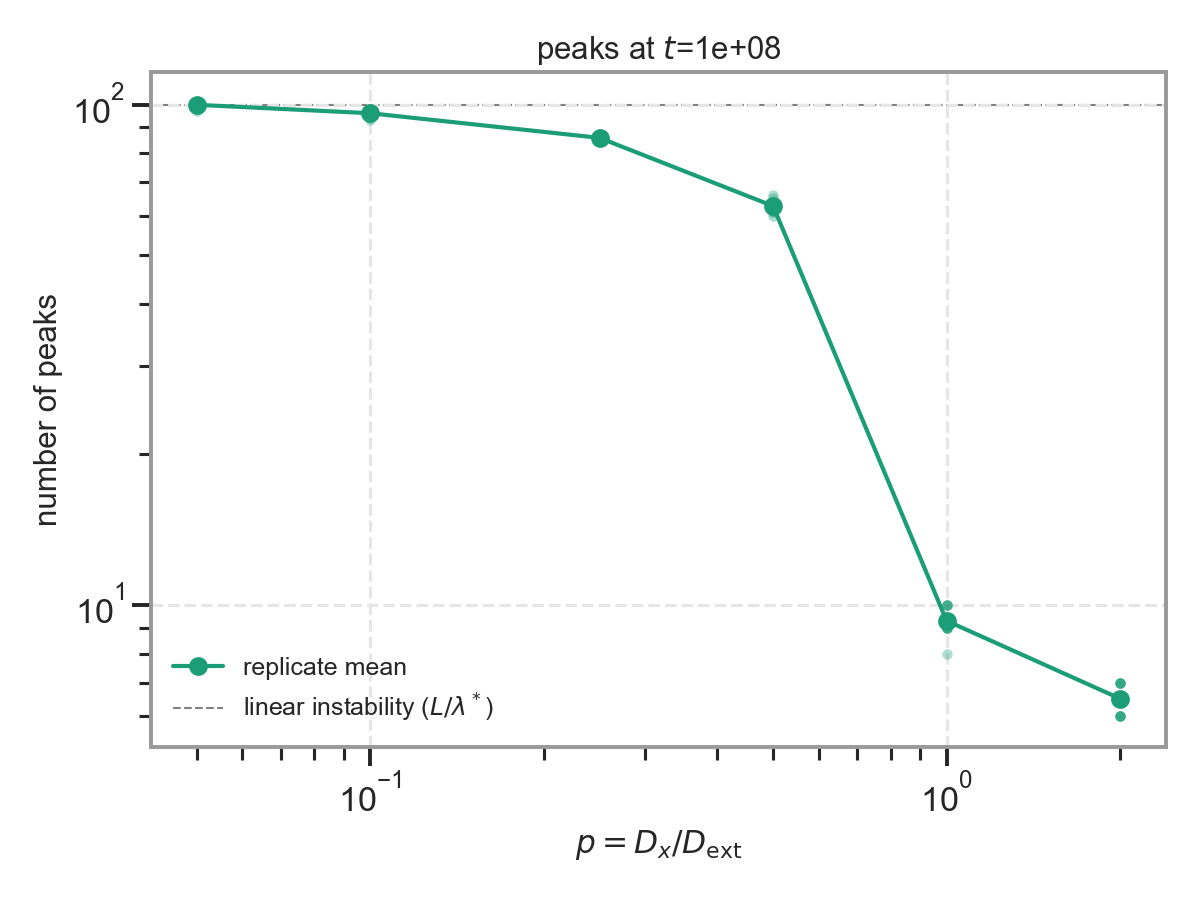

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_final_peaks(ax, ps, peaks[:, :, -1], n_peaks_target=n_peaks_target)
ax.legend(fontsize=12, frameon=False)
ax.set_title(f"peaks at $t$={t_max:g}")
fig.tight_layout()
plt.show()

## Notes on fidelity

Both figures are drawn by the `plot_peaks_vs_time` and `plot_final_peaks` defined
above -- transcribed from the scan's module and called with the same figure sizes,
legends, titles and `tight_layout` as `draw_figures` in the run script -- so the
content matches the saved files. Nothing had to be recomputed or substituted: the
linear-instability reference is the stored scalar `n_peaks`, and the summary
table's $k^*$ and growth rates are the stored `k_star` / `max_growth`.

The `%config InlineBackend.print_figure_kwargs` line at the top makes the inline
rasters come out at the same pixel size as the files on disk -- 1350x900 for the
peaks figure and 1200x900 for the final one -- so the two can be diffed directly.
Doing that leaves a residual of about 10/255 mean absolute difference, entirely of
two cosmetic kinds:

* **Font metrics.** This machine's text renders a hair wider or narrower than the
  cluster's did, and `tight_layout` sizes the margins from the text extents, so the
  axes box lands a few pixels off. Centred strings (the title) and the tick labels
  therefore sit up to ~5 px from where they sit in the saved PNG. Every curve,
  band, marker, tick and legend entry is otherwise the same.
* **Antialiasing.** The diff of the two images is an outline of every line and
  glyph, i.e. the edge pixels only, which is what a sub-pixel offset looks like.

Nothing is written to disk here -- there is no `savefig` anywhere in this notebook.

What could *not* be reproduced from the npz: nothing that either figure uses. For
completeness, the npz deliberately does **not** keep the spatial profiles (they
are counted and discarded inside `run_peaks`, which is what keeps the whole scan
in one 150 kB file), so kymographs or resource profiles would need the runs
redone; neither figure here needs them. The per-run solver messages are likewise
not stored, only the `success` flags -- all 60 runs succeeded.